# Phase 2 – Part A: Unsupervised Learning 

## 1. Imports <a id='imports'></a>

We import the core libraries needed for data handling, preprocessing, clustering, and visualization.  
`StandardScaler` and `LabelEncoder` handle feature preparation; `KMeans` is the main clustering algorithm;  
`PCA` is used later for dimensionality reduction and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

## 2. Data Loading <a id='data-loading'></a>

We load the raw dataset from the `/Dataset` folder.  
The dataset contains **10,000 bank customers** with features such as age, balance, credit score, geography, and whether they churned (`Exited`).

In [2]:
df = pd.read_csv("Dataset/Raw_Churn_Modelling_Data.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Data Preparation <a id='data-preparation'></a>

Before applying clustering, we must prepare the data through three steps:
1. **Remove identifier columns** — they carry no useful pattern information
2. **Remove the target label** — clustering is unsupervised; the label must not be seen
3. **Encode categorical variables** — K-Means requires numerical input
4. **Scale features** — ensures no single feature dominates due to its magnitude

### 3.1 Remove Identifier Columns

In [3]:
# RowNumber, CustomerId, and Surname are unique identifiers — not features.
# Including them would introduce noise and prevent meaningful clustering.
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)
print(f"Shape after dropping identifiers: {df.shape}")
df.head()

Shape after dropping identifiers: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 3.2 Remove the Target Label (`Exited`)

K-Means is an **unsupervised** algorithm — it must discover structure on its own without knowing the churn outcome.  
We remove `Exited` here and reintroduce it later only for proxy validation.

In [4]:
exited_labels = df["Exited"].copy()
df = df.drop("Exited", axis=1)

### 3.3 Encode Categorical Variables

`Gender` and `Geography` are categorical. K-Means computes Euclidean distances, so all features must be numeric.  
We use `LabelEncoder` to convert them to integers.

In [5]:
label_encoder = LabelEncoder()

df["Gender"] = label_encoder.fit_transform(df["Gender"])

df["Geography"] = label_encoder.fit_transform(df["Geography"])

print("Encoding complete. Sample:")
df[["Gender", "Geography"]].value_counts().head()

Encoding complete. Sample:


Gender  Geography
1       0            2753
0       0            2261
1       2            1388
        1            1316
0       1            1193
Name: count, dtype: int64

### 3.4 Feature Scaling

Features have very different ranges (e.g., `Balance` can be in the tens of thousands while `NumOfProducts` ranges from 1–4).  
Without scaling, high-magnitude features would dominate the distance calculations.  
`StandardScaler` transforms each feature to have **mean = 0** and **standard deviation = 1**.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Scaling complete.")
print(f"Mean of scaled data (should be ≈ 0): {X_scaled.mean():.4f}")
print(f"Std  of scaled data (should be ≈ 1): {X_scaled.std():.4f}")

Scaling complete.
Mean of scaled data (should be ≈ 0): -0.0000
Std  of scaled data (should be ≈ 1): 1.0000


## 4. Determining the Optimal Number of Clusters – Elbow Method <a id='elbow'></a>

K-Means requires us to specify **k** (number of clusters) in advance.  
The **Elbow Method** helps us choose k by plotting the **Within-Cluster Sum of Squares (WCSS)** for k = 1 to 10.

- **WCSS** measures the total squared distance between each point and its cluster centroid — lower means tighter clusters.
- As k increases, WCSS always decreases; we look for the point where the rate of decrease sharply slows — the "elbow".
- Beyond the elbow, adding more clusters gives diminishing returns.

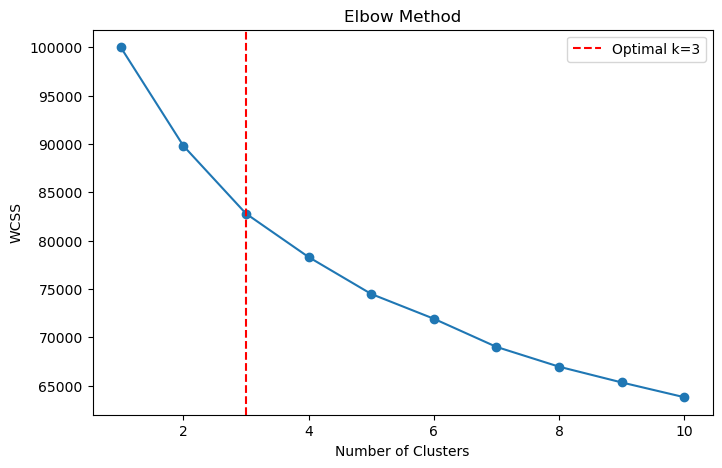

In [7]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.axvline(x=3, color='red', linestyle='--', label='Optimal k=3')
plt.legend()
plt.show()

**Observation:** The WCSS curve decreases steadily from k=1 to k=10 without a sharp, obvious elbow. The most noticeable change in slope occurs around **k=3**, where the rate of decrease begins to slow. While the elbow is not dramatic, k=3 represents a reasonable trade-off between cluster compactness and model simplicity. This is consistent with the low Silhouette Score, confirming that the data does not have strongly distinct natural groupings.

## 5. K-Means Model Training <a id='kmeans'></a>

We now train K-Means with **k = 3**.  
`random_state=42` ensures reproducibility. `n_init=10` (default) runs 10 different initialisations and selects the best result,  
reducing the risk of converging to a poor local minimum.

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("K-Means training complete.")
print(f"Cluster labels assigned: {sorted(df['Cluster'].unique())}")
df.head()

K-Means training complete.
Cluster labels assigned: [np.int32(0), np.int32(1), np.int32(2)]


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Cluster
0,619,0,0,42,2,0.00,1,1,1,101348.88,2
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,1


## 6. Cluster Evaluation Metrics <a id='evaluation'></a>

We evaluate cluster quality using three complementary metrics:

| Metric | What it measures | Better when |
|---|---|---|
| **Silhouette Score** | How well each point fits its cluster vs. neighbouring clusters | Closer to **1** |
| **Davies-Bouldin Index** | Average similarity between each cluster and its nearest cluster | **Lower** |
| **WCSS** | Compactness of clusters — total intra-cluster variance | **Lower** |

In [9]:
sil     = silhouette_score(X_scaled, clusters)
db      = davies_bouldin_score(X_scaled, clusters)
wcss_k3 = kmeans.inertia_

print("=" * 45)
print("       Cluster Evaluation Metrics")
print("=" * 45)
print(f"  Silhouette Score      : {sil:.4f}  (↑ higher is better, max = 1)")
print(f"  Davies-Bouldin Index  : {db:.4f}  (↓ lower is better)")
print(f"  WCSS at k=3           : {wcss_k3:.2f}")
print("=" * 45)

       Cluster Evaluation Metrics
  Silhouette Score      : 0.1070  (↑ higher is better, max = 1)
  Davies-Bouldin Index  : 2.6204  (↓ lower is better)
  WCSS at k=3           : 82788.88


**Interpretation:**
- A **Silhouette Score of 0.1070** is low, indicating that the clusters have significant overlap and many points sit close to the boundary between clusters. This is not unusual for customer datasets where groups naturally blend into each other.
- A **Davies-Bouldin Index of 2.6204** is relatively high (lower is better), further confirming that the clusters are not well-separated in the feature space.
- These results suggest that the customer data does not form strongly distinct natural groups. K-Means with k=3 still provides a useful segmentation for business purposes, but the separation is soft rather than clear-cut. This is a known limitation of applying K-Means to high-dimensional tabular data with overlapping customer behaviour.

## 7. Cluster Size Distribution <a id='distribution'></a>

A healthy clustering result produces clusters of **reasonably similar sizes**.  
Extreme imbalance (e.g., one cluster with 9,000 points and another with 20) would suggest the algorithm failed to find meaningful structure.

Customers per cluster:
Cluster
0    2940
1    4118
2    2942
Total: 10000


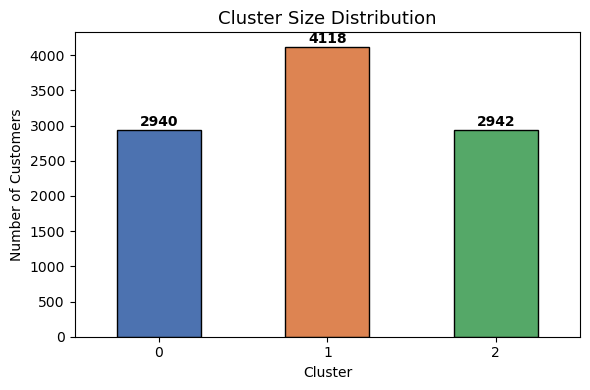

In [10]:
# Count and display
counts = df["Cluster"].value_counts().sort_index()
print("Customers per cluster:")
print(counts.to_string())
print("Total: " + str(counts.sum()))

# Bar chart
counts.plot(
    kind='bar',
    color=['#4C72B0', '#DD8452', '#55A868'],
    edgecolor='black',
    figsize=(6, 4)
)
plt.title("Cluster Size Distribution", fontsize=13)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Cluster 0 has 2,940 customers, Cluster 1 has 4,118, and Cluster 2 has 2,942. Clusters 0 and 2 are nearly identical in size, while Cluster 1 is noticeably larger — containing about 41% of all customers. This mild imbalance is acceptable and does not indicate a failure of the algorithm, but it does suggest that the low-balance mixed-gender segment (Cluster 1) is the most common customer profile in this dataset.

## 8. Cluster Profiling <a id='profiling'></a>

We examine the **mean of each feature per cluster** (using original unscaled values) to understand what characterises each customer segment.

In [11]:
cluster_profile = df.groupby("Cluster").mean()
cluster_profile

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
Cluster,,,,,,,,,,
0,651.385034,0.758503,0.541156,39.110204,4.914966,78053.305898,1.523129,0.0000,0.524490,100964.805626
1,649.919621,0.795289,0.552938,38.934434,5.022341,122587.045374,1.297232,1.0000,0.508256,100468.087688
2,650.525833,0.665534,0.540109,38.715840,5.097213,10390.455707,1.863358,0.9983,0.515296,98687.384490


**Cluster Profiles Summary:**

| Cluster | Key Characteristics | Interpretation |
|---|---|---|
| **0** | Balance ≈ 78,053, HasCrCard = 0.0 (no credit card), NumOfProducts ≈ 1.5 | Medium-balance customers with no credit card — moderately engaged |
| **1** | Balance ≈ 122,587 (highest), HasCrCard = 1.0, NumOfProducts ≈ 1.3 | High-balance customers with credit card — most financially stable, lowest churn risk |
| **2** | Balance ≈ 10,390 (lowest), HasCrCard ≈ 1.0, NumOfProducts ≈ 1.9 | Low-balance customers with more products — financially stretched, highest churn risk |

> **Note:** Gender is nearly identical across all clusters (~0.54) and is therefore not a distinguishing feature. The profile uses original feature values (not scaled), so the numbers are directly interpretable.

**Key insight:** The clustering separated customers primarily by **balance level and credit card ownership**. Cluster 0 is uniquely defined by having no credit card, while Clusters 1 and 2 differ mainly in balance — making balance the most defining feature in this dataset.

## 9. Cluster Visualization – PCA <a id='pca'></a>

Since the dataset has multiple dimensions, we use **Principal Component Analysis (PCA)** to project it into 2D for visualization.  
PCA finds the two directions that capture the most variance in the data, allowing us to plot all customers on a 2D scatter plot  
while preserving as much of the original structure as possible.

> Note: PCA is used **only for visualization** — clustering was performed on the full scaled dataset.

Variance explained — PC1: 13.21%, PC2: 11.03%
Total variance captured: 24.24%


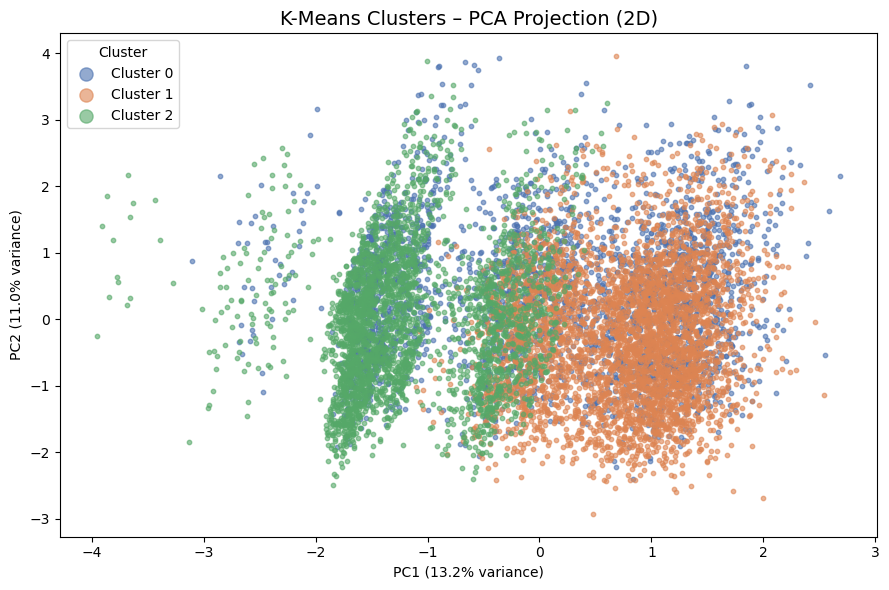

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"Variance explained — PC1: {explained[0]:.2%}, PC2: {explained[1]:.2%}")
print(f"Total variance captured: {sum(explained):.2%}")

# Plot with a proper legend
colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

plt.figure(figsize=(9, 6))
for c, col, lbl in zip([0, 1, 2], colors, labels):
    mask = df["Cluster"] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=col, label=lbl, s=10, alpha=0.6)

plt.title("K-Means Clusters – PCA Projection (2D)", fontsize=14)
plt.xlabel(f"PC1 ({explained[0]:.1%} variance)")
plt.ylabel(f"PC2 ({explained[1]:.1%} variance)")
plt.legend(title="Cluster", markerscale=3)
plt.tight_layout()
plt.show()

**Interpretation:**
- **Cluster 1 (orange)** forms the largest and most spread-out group on the right side of the plot. Despite its size, it heavily overlaps with Cluster 0 (blue), making visual separation difficult.
- **Cluster 2 (green)** is shifted toward the left (negative PC1), showing partial separation from the other groups. This is likely driven by its distinctly low balance (≈10,390) pulling it in a separate direction in the feature space.
- **Cluster 0 (blue)** is scattered across the entire plot, overlapping with both other clusters — reflecting that it shares some characteristics with both groups.
- The two principal components capture only **24.24% of the total variance**, meaning over 75% of the data structure is invisible in this 2D view. The heavy overlap seen here is largely a consequence of this information loss, not a failure of the clustering itself.
- This is consistent with the low Silhouette Score of 0.1070 and confirms that the clusters are not linearly separable in 2D, but may still represent meaningful segments in the full feature space.

## 10. Proxy Validation – Churn Rate per Cluster <a id='proxy'></a>

**BCubed Precision/Recall** requires predefined ground-truth cluster labels, which are unavailable in a purely unsupervised setting.  

As a proxy, we reintroduce the original `Exited` column (which was removed before clustering) and examine  
how churn is distributed across clusters. If the clusters show **meaningfully different churn rates**, it confirms  
that the algorithm captured real customer differences — even without being given the labels during training.

Churn rate per cluster:
Cluster
0    0.206803
1    0.224866
2    0.170972
Name: Exited, dtype: float64


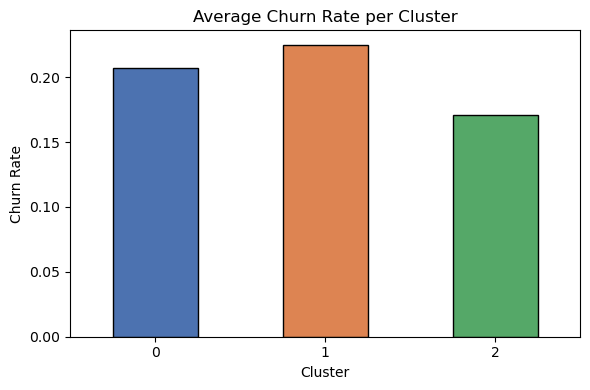

In [13]:
df["Exited"] = exited_labels.values  # add back for analysis only

churn_by_cluster = df.groupby("Cluster")["Exited"].mean()
print("Churn rate per cluster:")
print(churn_by_cluster)

churn_by_cluster.plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'],
                      edgecolor='black', figsize=(6,4))
plt.title("Average Churn Rate per Cluster")
plt.xlabel("Cluster"); plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df.drop("Exited", axis=1, inplace=True)  # remove again after

**Interpretation:**
- **Cluster 1** has the highest churn rate at **22.5%**, despite having the highest balance (≈122,587). This is unexpected and suggests that high balance alone does not guarantee loyalty — other factors such as geography or activity level may influence churn in this group.
- **Cluster 0** follows at **20.7%**, representing medium-balance customers with no credit card — moderately at risk.
- **Cluster 2** has the lowest churn rate at **17.1%**, despite having the lowest balance (≈10,390). This is counterintuitive and suggests that low-balance customers in this cluster may be retained for reasons not captured by balance alone.
- The differences between clusters are **relatively small** (~5 percentage points), consistent with the low Silhouette Score of 0.1070 — the clustering did not produce strongly separated risk groups.
- Overall, this proxy validation shows that **balance and credit card ownership are not reliable predictors of churn** when used as the sole basis for clustering, highlighting the complexity of customer behaviour in this dataset.